### Langchain Version V1

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]= os.getenv("groq")

In [7]:
from langchain.chat_models import init_chat_model
model= init_chat_model("groq:openai/gpt-oss-120b")

In [9]:
model.invoke("write 200 word essay on car")

AIMessage(content="Cars have become an integral part of modern life, shaping how people travel, work, and experience freedom. Since the invention of the internal‑combustion engine in the late 19th century, automobiles evolved from simple mechanical curiosities into sophisticated machines equipped with advanced electronics, safety systems, and connectivity features. This evolution reflects broader technological progress and societal demands for speed, comfort, and efficiency.  \n\nBeyond transportation, cars influence economies, culture, and the environment. The automotive industry supports millions of jobs worldwide, from manufacturing and design to sales and maintenance. Culturally, cars symbolize status, individuality, and adventure; they appear in literature, film, and music as icons of personal expression. However, the widespread reliance on gasoline‑powered vehicles contributes to air pollution, greenhouse‑gas emissions, and resource depletion, prompting urgent calls for cleaner a

In [20]:
for chunk in model.stream("write 200 word essay on car"):
    print(chunk.content, end="", flush=True)

Cars have become more than mere machines; they are cultural icons that shape how we live, work, and imagine the future. Since Karl Benz’s first automobile rolled onto the streets in 1886, the vehicle has evolved from a noisy, steam‑powered curiosity into a sophisticated, computer‑controlled system. Modern cars blend engineering precision with digital intelligence, offering safety features such as adaptive cruise control, lane‑keeping assistance, and autonomous emergency braking. These advances have dramatically reduced traffic fatalities and transformed daily commutes into smoother, more predictable experiences.

Beyond practicality, cars symbolize personal freedom. The open road invites exploration, turning travel into a personal narrative of discovery. Yet this freedom comes with responsibility. The environmental impact of fossil‑fuel engines has spurred a rapid shift toward electrification, with governments and manufacturers investing heavily in battery technology, charging infrastr

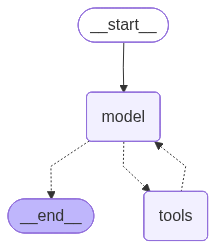

In [3]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """Get the weather at a location"""
    return f"It's Sunny in {city}"
agent=create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[get_weather],
    system_prompt="you are a helpful assisrant."
)
agent

## Batch
Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel.

In [22]:
responses= model.batch([
    "where is new york",
    "how aeroplane fly",
    "what is physics"
],
config={
    'max_concurrency':5,
}
)
for response in responses:
    print(response)

content='**New\u202fYork** can refer to two related places in the United States:\n\n| Place | What it is | Where it is (geographically) | Approx. coordinates |\n|-------|------------|------------------------------|---------------------|\n| **New\u202fYork State** | One of the 50 U.S. states, the 27th largest by area and 4th most populous. | In the **Northeastern** part of the country, bordering Canada to the north, Vermont, Massachusetts, Connecticut, New\u202fJersey, and Pennsylvania. Its western edge touches the Great Lakes (Lake Erie and Lake Ontario). | Roughly **42.9°\u202fN,\u202f75.5°\u202fW** (center of the state). |\n| **New\u202fYork City (NYC)** | The largest city in the United States, made up of five boroughs (Manhattan, Brooklyn, Queens, The Bronx, Staten Island). | Located in the **southern tip of New\u202fYork State**, at the mouth of the Hudson River where it meets the Atlantic Ocean. | About **40.7128°\u202fN,\u202f74.0060°\u202fW**. |\n\n### Quick visual\n\n- **Map of